# Customer Churn Prediction Using Machine Learning

## Business Problem

Customer churn is one of the most important challenges faced by subscription-based businesses. Acquiring new customers is often more expensive than retaining existing ones. The objective of this project is to develop a machine learning model capable of predicting whether a customer is likely to leave the telecom service based on demographic information, account details, and service usage patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

pd.set_option('display.max_columns', None)

## Dataset Loading

The IBM Telco Customer Churn dataset contains customer demographic information, subscription details, billing information, and churn status.

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

The TotalCharges column contains blank values that must be converted to numeric values. Missing values are replaced using the median value of the column. The customerID column is removed because it does not contribute to churn prediction.

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df.drop("customerID", axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Exploratory Data Analysis

The objective of EDA is to understand customer behavior patterns and identify factors associated with customer churn.

### Churn Distribution

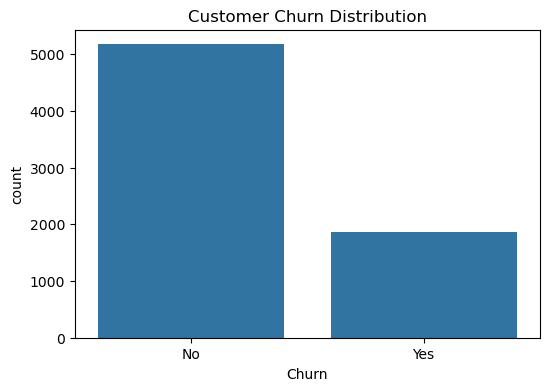

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True)*100)

Observation:

Approximately 26.5% of customers churned while 73.5% remained with the company. This indicates a moderate class imbalance.

### Contract Type vs Churn

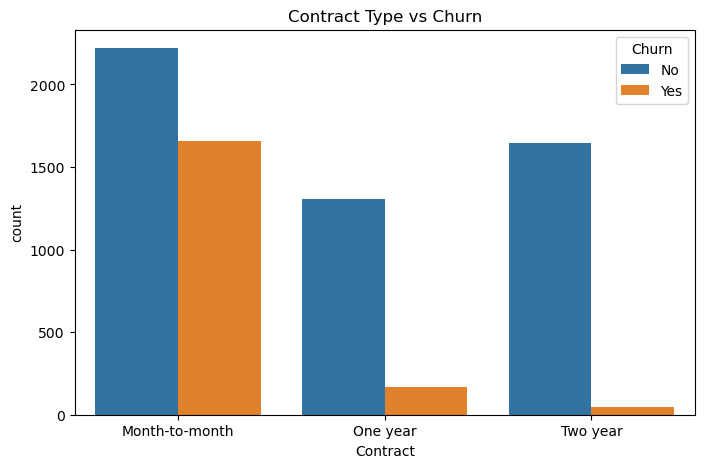

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Contract Type vs Churn')
plt.show()

Observation:

Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers with one-year and two-year contracts.

### Tenure vs Churn

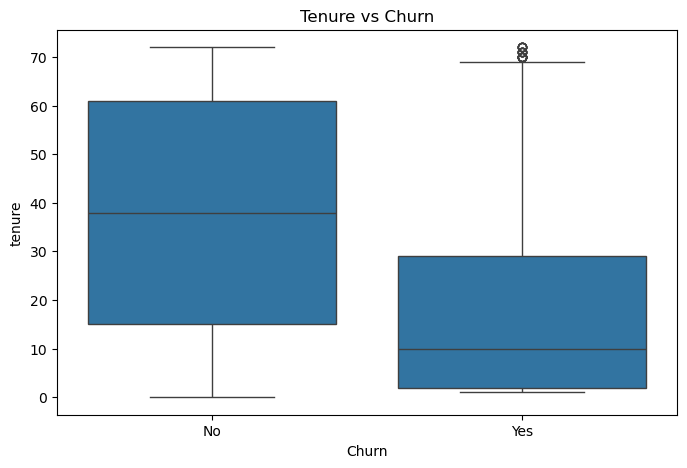

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure vs Churn')
plt.show()

Observation:

Customers with shorter tenure are more likely to churn, indicating that retention efforts should focus on recently acquired customers.

### Monthly Charges vs Churn

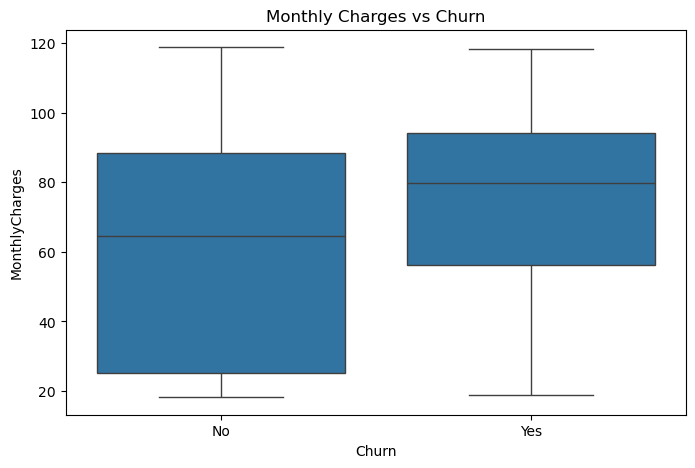

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Churn')
plt.show()

Observation:

Customers with higher monthly charges tend to exhibit higher churn rates.

### Internet Service vs Churn

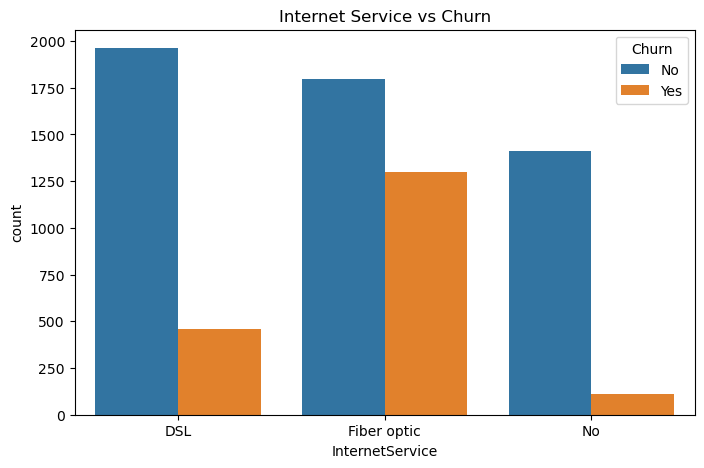

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title('Internet Service vs Churn')
plt.show()

Observation:

Fiber optic customers show relatively higher churn rates compared to customers using DSL or no internet service.

## Feature Engineering

Categorical variables are converted into numerical features using one-hot encoding. The target variable is transformed into binary format.

In [10]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(7043, 30)


## Train-Test Split and Scaling

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

In [12]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Accuracy: 0.8069552874378992


## Random Forest Model

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.7899219304471257


## Model Evaluation

In [14]:
roc_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:,1]
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.826492546952905


## Feature Importance Analysis

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.194123
1,tenure,0.171364
2,MonthlyCharges,0.167562
10,InternetService_Fiber optic,0.038864
28,PaymentMethod_Electronic check,0.038285
25,Contract_Two year,0.031477
4,gender_Male,0.028519
13,OnlineSecurity_Yes,0.027796
26,PaperlessBilling_Yes,0.025725
5,Partner_Yes,0.023285


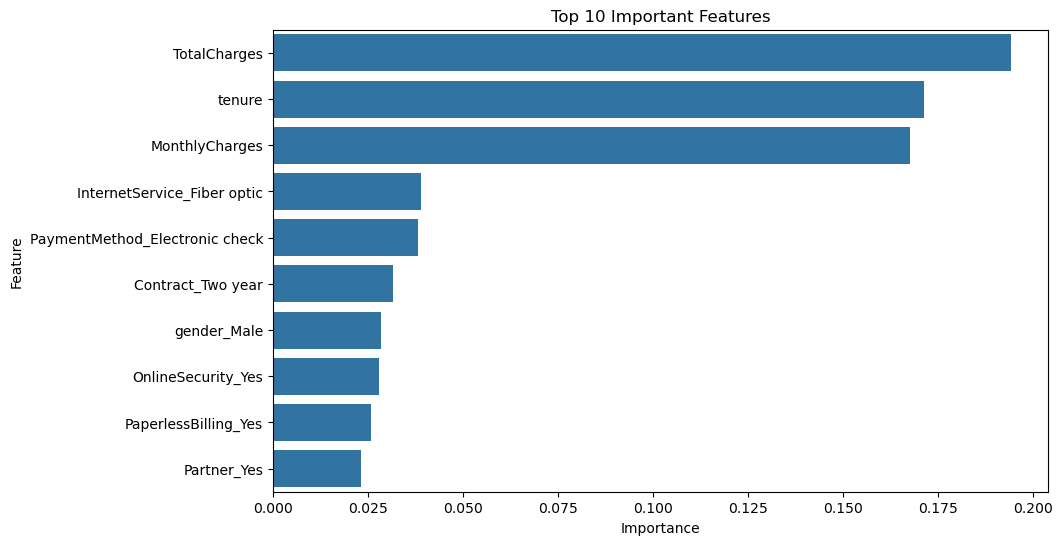

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

## Key Findings

• Customers with lower tenure are more likely to churn.

• Month-to-month contracts exhibit the highest churn rates.

• Higher monthly charges are associated with increased churn.

• Fiber optic customers demonstrate relatively higher churn.

• Contract type, tenure, and billing-related features are among the strongest churn predictors.

## Conclusion

This project developed machine learning models to predict telecom customer churn using demographic, service, and billing information. Logistic Regression achieved approximately 80.7% accuracy, while Random Forest achieved a ROC-AUC score of approximately 0.826. Feature importance analysis identified TotalCharges, tenure, MonthlyCharges, and contract type as key drivers of customer churn. These insights can help businesses design targeted customer retention strategies and reduce customer attrition.